# 07 — Domain-stratified (proposal 3.3.7) → RQ3

In [1]:
%load_ext autoreload
%autoreload 2

import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))  # so `import src...` works from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.utils import set_seed, save_fig
set_seed()  # fix all RNGs -- reproducibility

Re-run core classification per domain (8 of them). Report per-class F1, confusion, feature importance per domain.

In [2]:
from src import data, features, analysis, viz
clean = data.load_or_build_clean(); splits = data.load_or_build_splits(clean)
texts = clean['text']

X_tfidf, _ = features.build_tfidf(texts.iloc[splits['train']], texts)
sty = features.build_stylometric(texts)
sty_scaled, _ = features.scale_dense(sty.values, splits['train'])
bib = features.build_biber(texts)
bib_scaled, _ = features.scale_dense(bib.values, splits['train'])
emb = features.build_sbert(texts)   # cached

feature_blocks = {'tfidf': X_tfidf, 'stylometric': sty_scaled, 'biber': bib_scaled, 'sbert': emb,
                   'length': clean[['log_token_count']].values}

In [3]:
per_domain = analysis.run_per_domain(clean, splits, feature_blocks, 'logreg')
per_domain.to_csv(config.ARTIFACTS / 'per_domain_results.csv', index=False)

pivot = per_domain.pivot_table(index='domain', columns='class', values='f1').reindex(columns=config.CLASSES)
pivot

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


class,human,chatgpt,gpt4,gpt3,gpt2,llama-chat,mistral,mistral-chat,mpt,mpt-chat,cohere,cohere-chat
domain,,,,,,,,,,,,
abstracts,0.916179,0.842308,0.962963,0.863905,0.870588,0.940945,0.738337,0.825832,0.719536,0.855984,0.709552,0.658228
books,0.925430,0.934615,0.976285,0.904762,0.950884,0.935421,0.797665,0.897485,0.774194,0.877670,0.778226,0.784394
news,0.864000,0.922465,0.899804,0.770459,0.705411,0.814815,0.616302,0.737052,0.554865,0.716599,0.629703,0.481172
poetry,0.888016,0.912698,0.976096,0.828866,0.595483,0.881764,0.485477,0.706638,0.554415,0.698347,0.708861,0.701961
recipes,0.978389,0.957746,0.972222,0.968504,0.960474,0.977956,0.960000,0.930769,0.935421,0.944444,0.853175,0.838583
reddit,0.751938,0.795276,0.844530,0.684426,0.684105,0.891473,0.685371,0.669307,0.621881,0.703777,0.560636,0.432323
reviews,0.929889,0.981413,0.988930,0.891473,0.900000,0.981273,0.676580,0.937729,0.673835,0.909774,0.700361,0.679389
wiki,0.812261,0.901575,0.865079,0.654618,0.813492,0.803922,0.573840,0.690335,0.636535,0.677228,0.497217,0.477733


PosixPath('/Users/xinye/Desktop/module 3/5 nautral language proccesing/syndicate asm/llm-source-attribution/figures/per_domain_f1_heatmap.png')

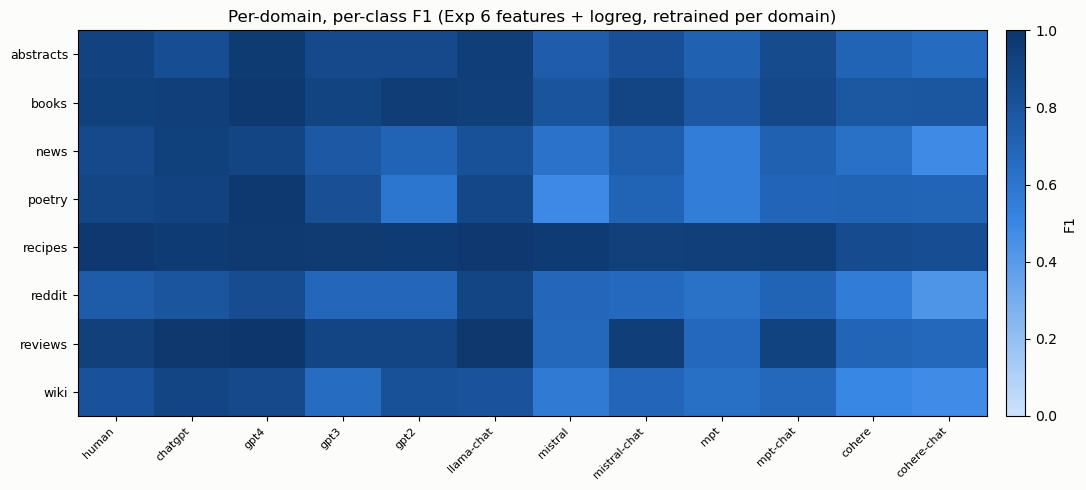

In [4]:
fig, ax = plt.subplots(figsize=(11, 5), facecolor=viz.SURFACE)
im = ax.imshow(pivot.values, cmap=viz.SEQUENTIAL_BLUE, vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_title('Per-domain, per-class F1 (Exp 6 features + logreg, retrained per domain)')
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('F1')
fig.tight_layout()
save_fig(fig, 'per_domain_f1_heatmap')

PosixPath('/Users/xinye/Desktop/module 3/5 nautral language proccesing/syndicate asm/llm-source-attribution/figures/per_domain_macro_f1.png')

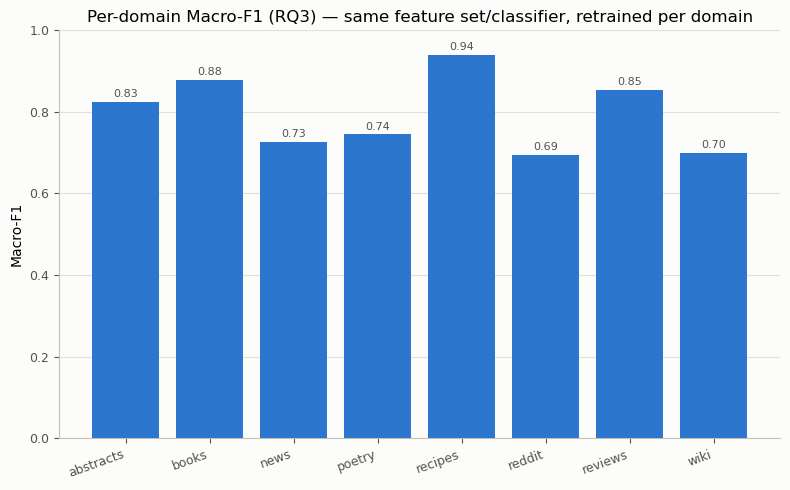

In [5]:
domain_macro = per_domain.drop_duplicates('domain').set_index('domain')['macro_f1_domain'].reindex(config.DOMAINS)

fig, ax = viz.new_fig(figsize=(8, 5))
x = np.arange(len(domain_macro))
bars = ax.bar(x, domain_macro.values, color=viz.SEQUENTIAL_BLUE(0.6), zorder=3)
ax.bar_label(bars, fmt='%.2f', fontsize=8, color=viz.INK_SECONDARY, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(domain_macro.index, rotation=20, ha='right')
ax.set_ylabel('Macro-F1')
ax.set_ylim(0, 1)
ax.set_title('Per-domain Macro-F1 (RQ3) — same feature set/classifier, retrained per domain')
fig.tight_layout()
save_fig(fig, 'per_domain_macro_f1')

Wrap up: collect the RQ1–RQ3 tables/figures for the report.

In [6]:
print('Figures for the report:', sorted(p.name for p in config.FIGURES.glob('*.png')))
print('Result tables:', sorted(p.name for p in config.ARTIFACTS.glob('*.csv')))

Figures for the report: ['ablation_macro_f1.png', 'centroid_cosine_heatmap.png', 'centroid_dendrogram.png', 'class_feature_means_heatmap.png', 'confusion_dendrogram.png', 'confusion_matrix_heatmap.png', 'detection_vs_attribution.png', 'domain_human_distance.png', 'final_test_confusion_matrix.png', 'final_test_results.png', 'per_domain_f1_heatmap.png', 'per_domain_macro_f1.png', 'style_coefficients_heatmap.png', 'within_vs_cross_family_confusion.png']
Result tables: ['ablation_results.csv', 'class_feature_means.csv', 'detection_vs_attribution.csv', 'final_test_results.csv', 'per_domain_results.csv', 'sentence_length_v2.csv']


### Conclusion (RQ3)

**Domain difficulty ranking (Macro-F1, best → worst): recipes (0.94) >
books (0.88) > reviews (0.85) > abstracts (0.83) > poetry (0.75) >
news (0.73) > wiki (0.70) > reddit (0.69).** A ~0.25 spread between the
easiest and hardest domain — domain context clearly matters for deployment,
as the proposal anticipated.

**This contradicts one specific part of the proposal's stated hypothesis.**
§3.3.7 predicted informal domains like Reddit would make lexical/n-gram
features *more* discriminative ("LLMs may struggle to replicate casual
language use"). The opposite happened: **Reddit is the single hardest
domain**, tied with Wiki. Recipes — the most rigidly *structured* domain
(ingredient lists, numbered steps) — is by far the easiest, which does fit
the proposal's other prediction (structured domains constrain stylometric
variation) but for the opposite reason than expected: rigid structure
apparently makes sources *more* separable here, not less, maybe because it
strips away the topic/content variation that otherwise dominates and leaves
only the formatting/phrasing choices that do vary by source.

**Two findings replicate across all three analysis notebooks now** (05
confusion patterns, 06 embedding distance, 07 per-domain classification —
three independent methods agreeing is strong evidence, not coincidence):

- **`gpt2` has the widest per-domain F1 swing of any class** (0.595 in
  poetry → 0.960 in recipes, a 0.365 range) — the same domain-instability
  pattern 06 found in its embedding-distance-to-human error bars. gpt2 isn't
  just the hardest class on average, it's the *least predictable* one.
- **`cohere-chat` is consistently among the worst-classified sources**,
  especially in free-form domains (reddit 0.43, wiki 0.48, news 0.48) —
  reinforcing 05/06's RQ2 finding that the Cohere family is the most
  human-adjacent: it's hardest to pin down precisely where human writing
  itself supplies the most natural variation, and easiest in recipes (0.84)
  where rigid structure limits everyone's room to sound human-like.
- **`mistral` and `mpt` (the base-model outlier pair from 05/06) are weak
  across the board**, worst in poetry and news (mistral 0.49/0.62, mpt
  0.55/0.55) — the same two models that clustered apart from everything
  else in both the confusion dendrogram and the embedding dendrogram show
  up here as the hardest to classify correctly, particularly outside
  recipes' rigid structure.

This whole notebook is effectively cross-checking RQ2's model-similarity
findings under a domain lens, which is exactly the point of keeping RQ3
(domain) as its own question rather than folding it into RQ2 too — it adds a
dimension (domain) that RQ2's aggregate analysis can't see on its own.